### Load Python packages and configure some global settings

In [1]:
# Import Python packages
import pandas as pd
import numpy as np
#!pip install matplotlib==3.1.3
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.sparse
import os, sys, wget, pickle
import bbknn
import scrublet as scr
from IPython.display import Image
from IPython.display import display

# Suppress 'FutureWarnings'
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Don't limit pandas column #
pd.options.display.max_columns=None

In [6]:
from matplotlib.pyplot import rc_context

### load

In [7]:
adata_Verzi = sc.read_10x_h5('/home/tht38/spatial.python/rep2/filtered_feature_bc_matrix.h5')
adata_Verzi.obs['n_counts'] = adata_Verzi.X.sum(1).A1
#adata_features.uns['library_id'] = 'features'
#adata_features.obs['library_id'] = np.tile('features', [adata_features.n_obs, 1])
adata_Verzi.var_names_make_unique()

/home/tht38/anaconda3/envs/newenv/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/tht38/anaconda3/envs/newenv/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [12]:
sample_info = pd.read_csv("/home/tht38/spatial.python/rep2/FullSamples.NoC2 (1).csv", index_col=0)

In [13]:
adata_Verzi.obs["time"] = sample_info["FullSamples.NoC2"].reindex(adata_Verzi.obs.index)

In [14]:
adata_Verzi.obs['time'].unique()

array(['D3', 'D1', 'D2', 'D5', 'D0', nan], dtype=object)

In [15]:
sample_info = pd.read_csv("/home/tht38/spatial.python/rep2/25.4.8 villus epi and stroma D0 and D3.csv", index_col=0)

In [16]:
adata_Verzi.obs["stromalregions"] = sample_info["Stromal regions"].reindex(adata_Verzi.obs.index)

In [ ]:
adata_Verzi.obs['time'] = adata_Verzi.obs['time'].astype('category')

In [19]:
adata_Verzi.obs['time'] = adata_Verzi.obs['time'].cat.reorder_categories(['D0', 'D1', 'D2', 'D3', 'D5'], ordered=True)

### normalized analyses

In [8]:
adata_Verzi

AnnData object with n_obs × n_vars = 397346 × 19059
    obs: 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome'

In [9]:
adata_Verzi.obs

,n_counts
s_008um_00269_00526-1,422.0
s_008um_00547_00611-1,951.0
s_008um_00693_00628-1,539.0
s_008um_00137_00810-1,172.0
s_008um_00660_00606-1,1072.0
...,...
s_008um_00565_00596-1,564.0
s_008um_00610_00321-1,321.0
s_008um_00172_00448-1,603.0
s_008um_00239_00812-1,556.0


In [ ]:
adata_Verzi = adata_Verzi[adata_Verzi.obs['n_counts'] > 40].copy()

In [10]:
sc.pp.normalize_per_cell(adata_Verzi, counts_per_cell_after=10**6)
sc.pp.log1p(adata_Verzi)


In [81]:
#sc.pl.dotplot(filtered_adata, ['Cad', 'Dhodh', 'Umps', 'Nme1', 'Nme2', 'Ctps'], groupby = 'time', standard_scale = 'var')

In [71]:
keep_values = ["D0", 'D3']
adata_Verzi = adata_Verzi[adata_Verzi.obs['time'].isin(keep_values)].copy()

In [72]:
keep_values = ["Day 0 crypt", "Day 0 tip C4", "Day 0 Mature epi C1", "Day 0 Young villus C8", "Day 0 junction C7", "D0 Villus stroma", "D0 Intercrypt", "D0 Subcrypt", "Day 3 Crypt C5", "Day 3 intercrypt", "Day 3 Junction C10", "Day 3 subcrypt", "Day 3 tip", "day 3 villus", "Day 3 Villus epi C13"]
adata_Verzi = adata_Verzi[adata_Verzi.obs['stromalregions'].isin(keep_values)].copy()

In [74]:
adata_Verzi

AnnData object with n_obs × n_vars = 123640 × 19059
    obs: 'n_counts', 'time', 'stromalregions'
    var: 'gene_ids', 'feature_types', 'genome'

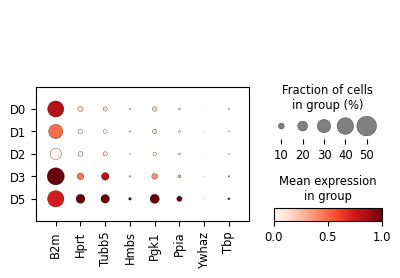

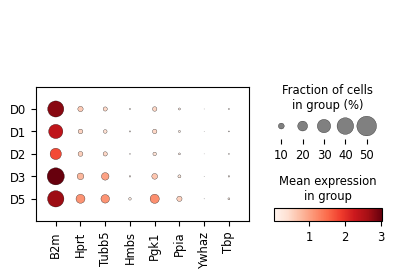

In [ ]:
genes = ["B2m", "Hprt",
    "Tubb5", "Hmbs", "Pgk1", "Ppia", "Ywhaz", "Tbp"
]

sc.pl.dotplot(adata_Verzi, genes, groupby = 'time', standard_scale = 'var')
sc.pl.dotplot(adata_Verzi, genes, groupby = 'time')


In [42]:
sc.set_figure_params(dpi=300, figsize=(4,4), fontsize=8)

In [ ]:
fts = ['Tgfb1','Acvr1b', 'Tgfbr2','Tgfbr1', 'Acvr1','Acvr1c', 'Tgfb2','Tgfb3']
sc.pl.dotplot(adata_Verzi, fts, groupby = 'time')
fts = ['Tgfb1','Acvr1b', 'Tgfbr2','Tgfbr1', 'Acvr1']
sc.pl.dotplot(adata_Verzi, fts, groupby = 'time')

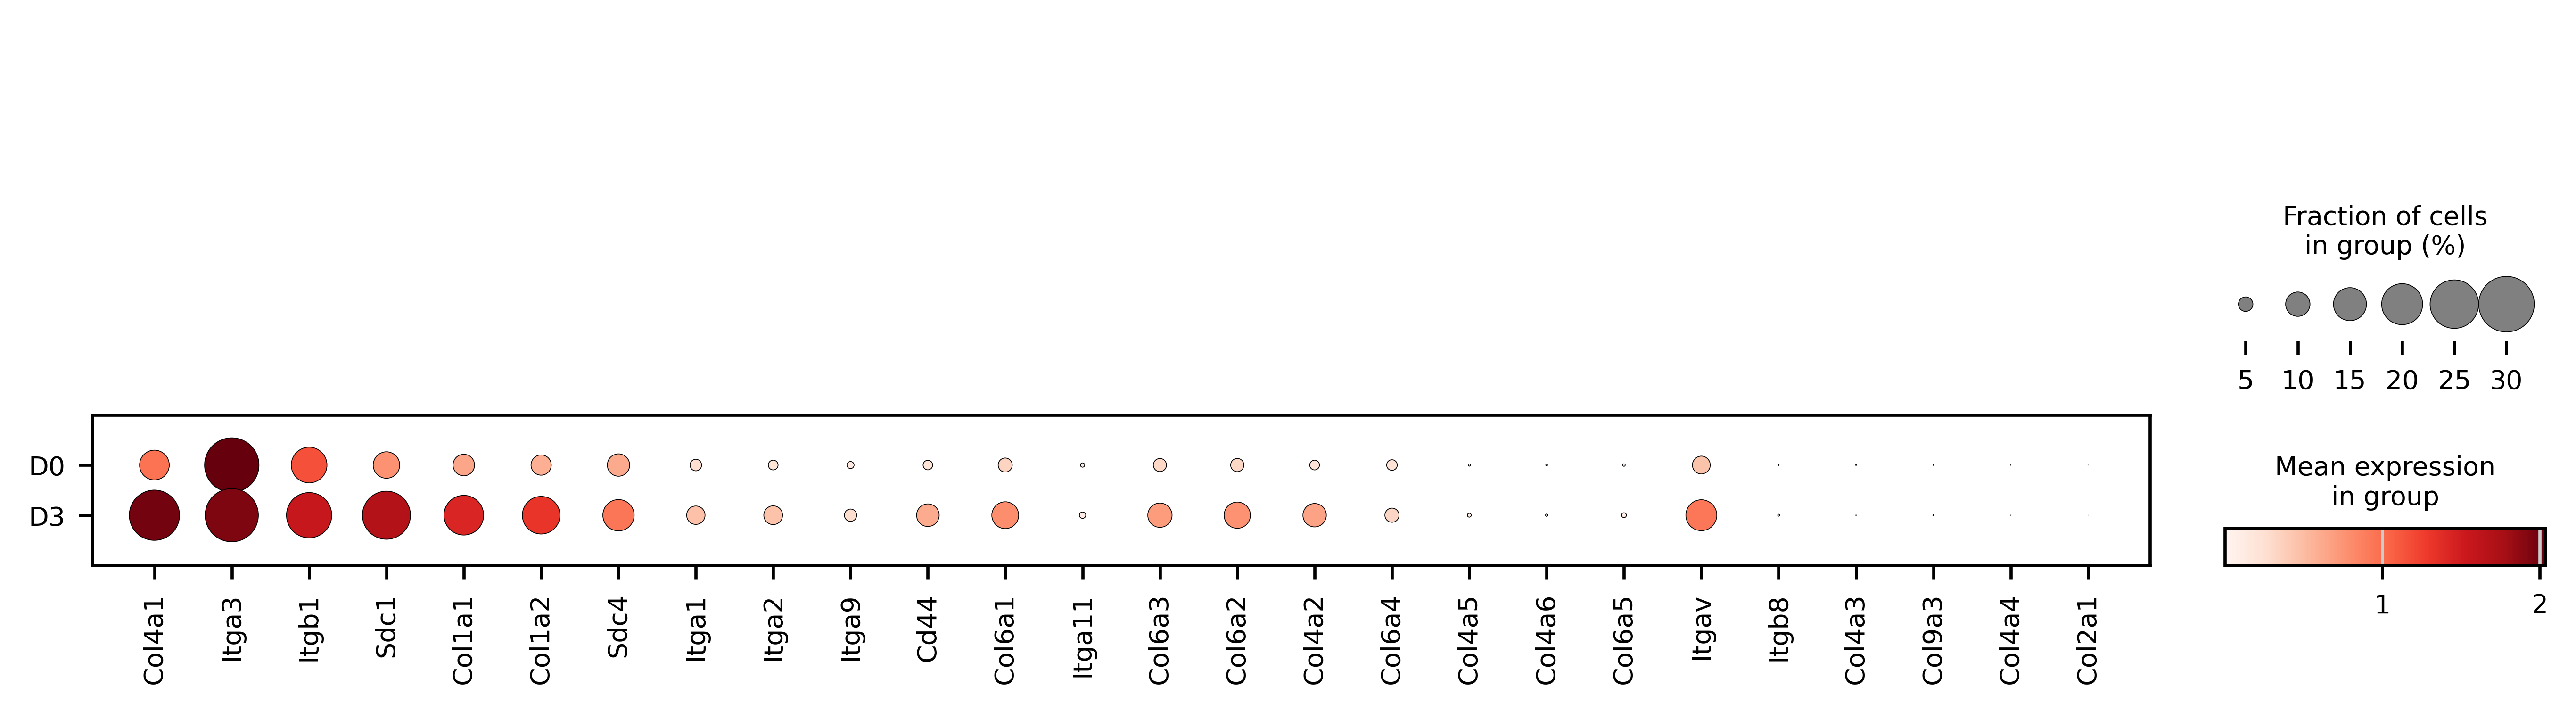

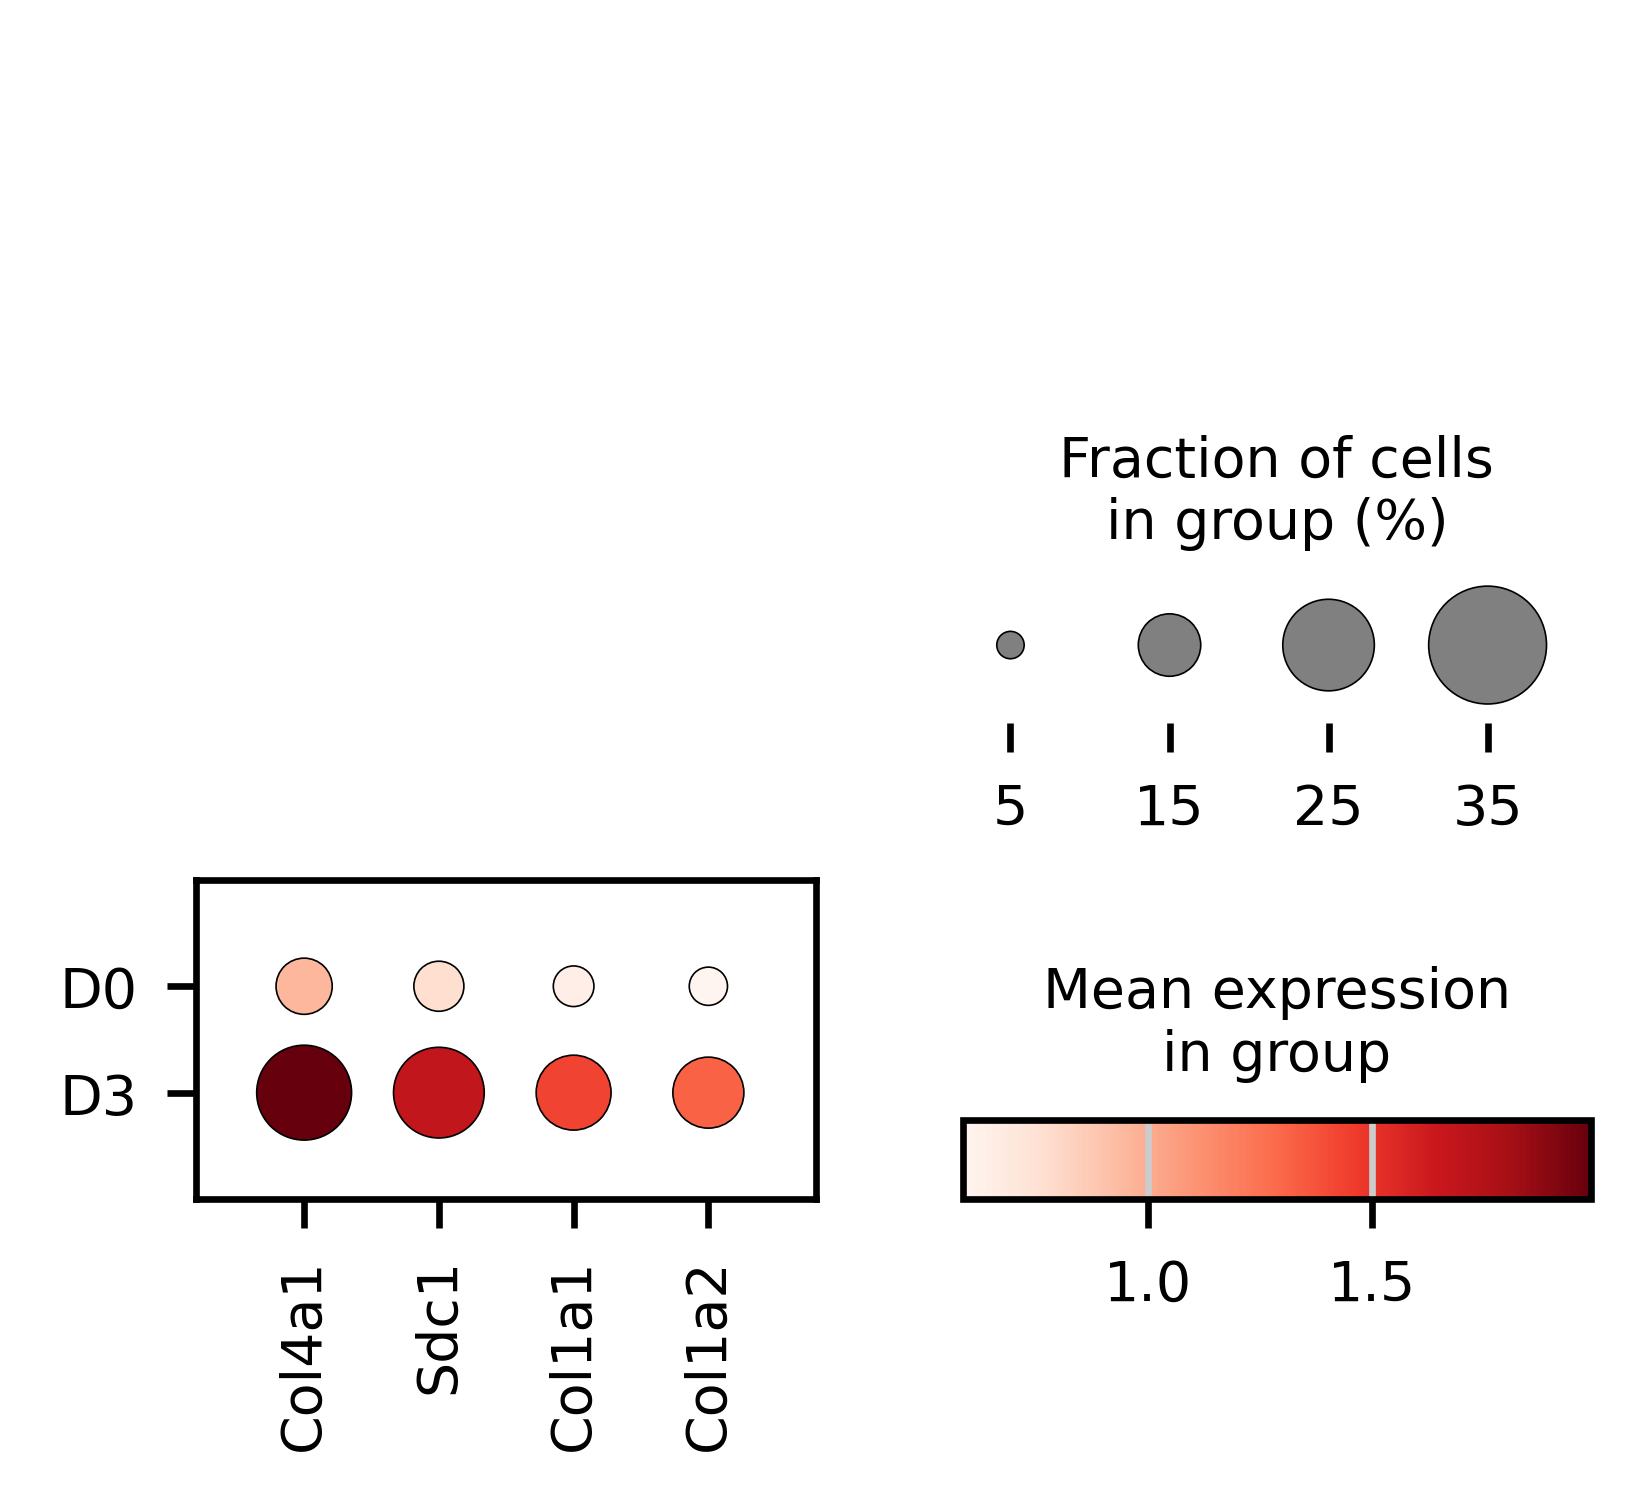

In [ ]:
fts = ['Col4a1', 'Itga3', 'Itgb1', 'Sdc1', 'Col1a1', 'Col1a2', 'Sdc4', 
         'Itga1', 'Itga2', 'Itga9', 'Cd44', 'Col6a1', 'Itga11', 'Col6a3', 
         'Col6a2', 'Col4a2', 'Col6a4', 'Col4a5', 'Col4a6', 'Col6a5', 
         'Itgav', 'Itgb8', 'Col4a3', 'Col9a3', 'Col4a4', 'Col2a1']
sc.pl.dotplot(adata_Verzi, fts, groupby = 'time')
fts = ['Col4a1', 'Sdc1', 'Col1a1', 'Col1a2']
sc.pl.dotplot(adata_Verzi, fts, groupby = 'time')


In [ ]:
sc.pl.matrixplot(adata_Verzi, fts, groupby='time', cmap = 'bwr')

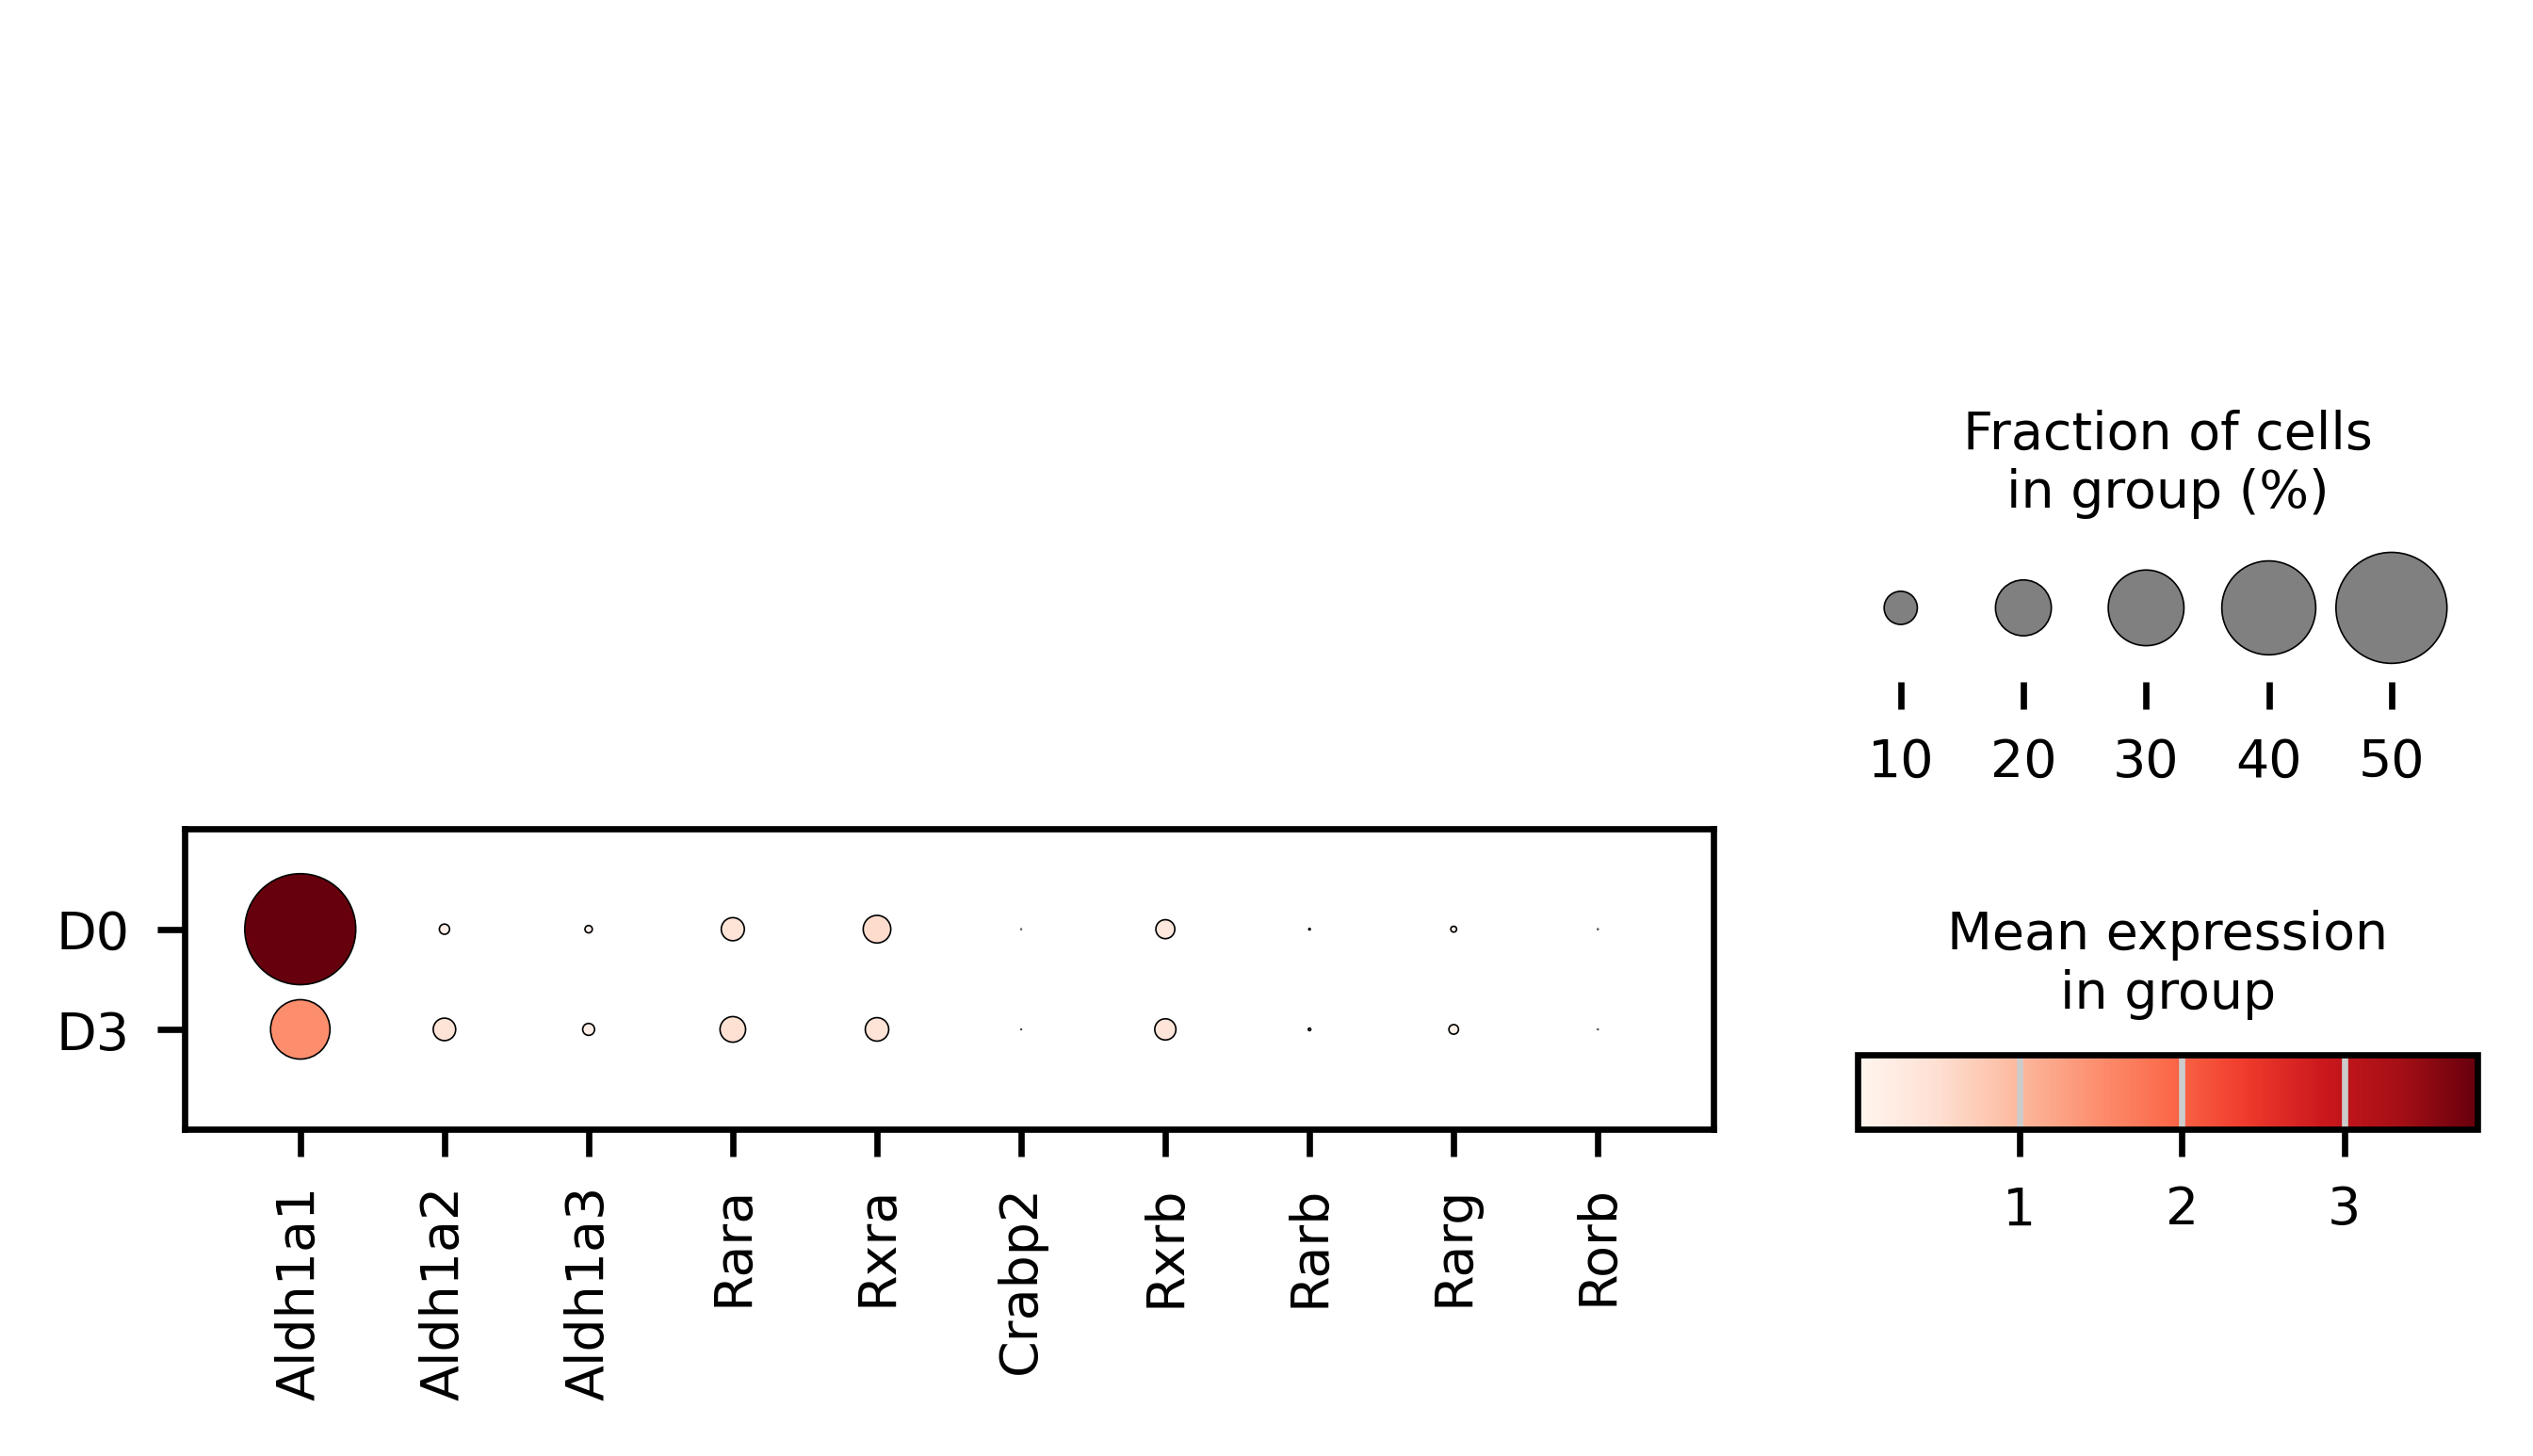

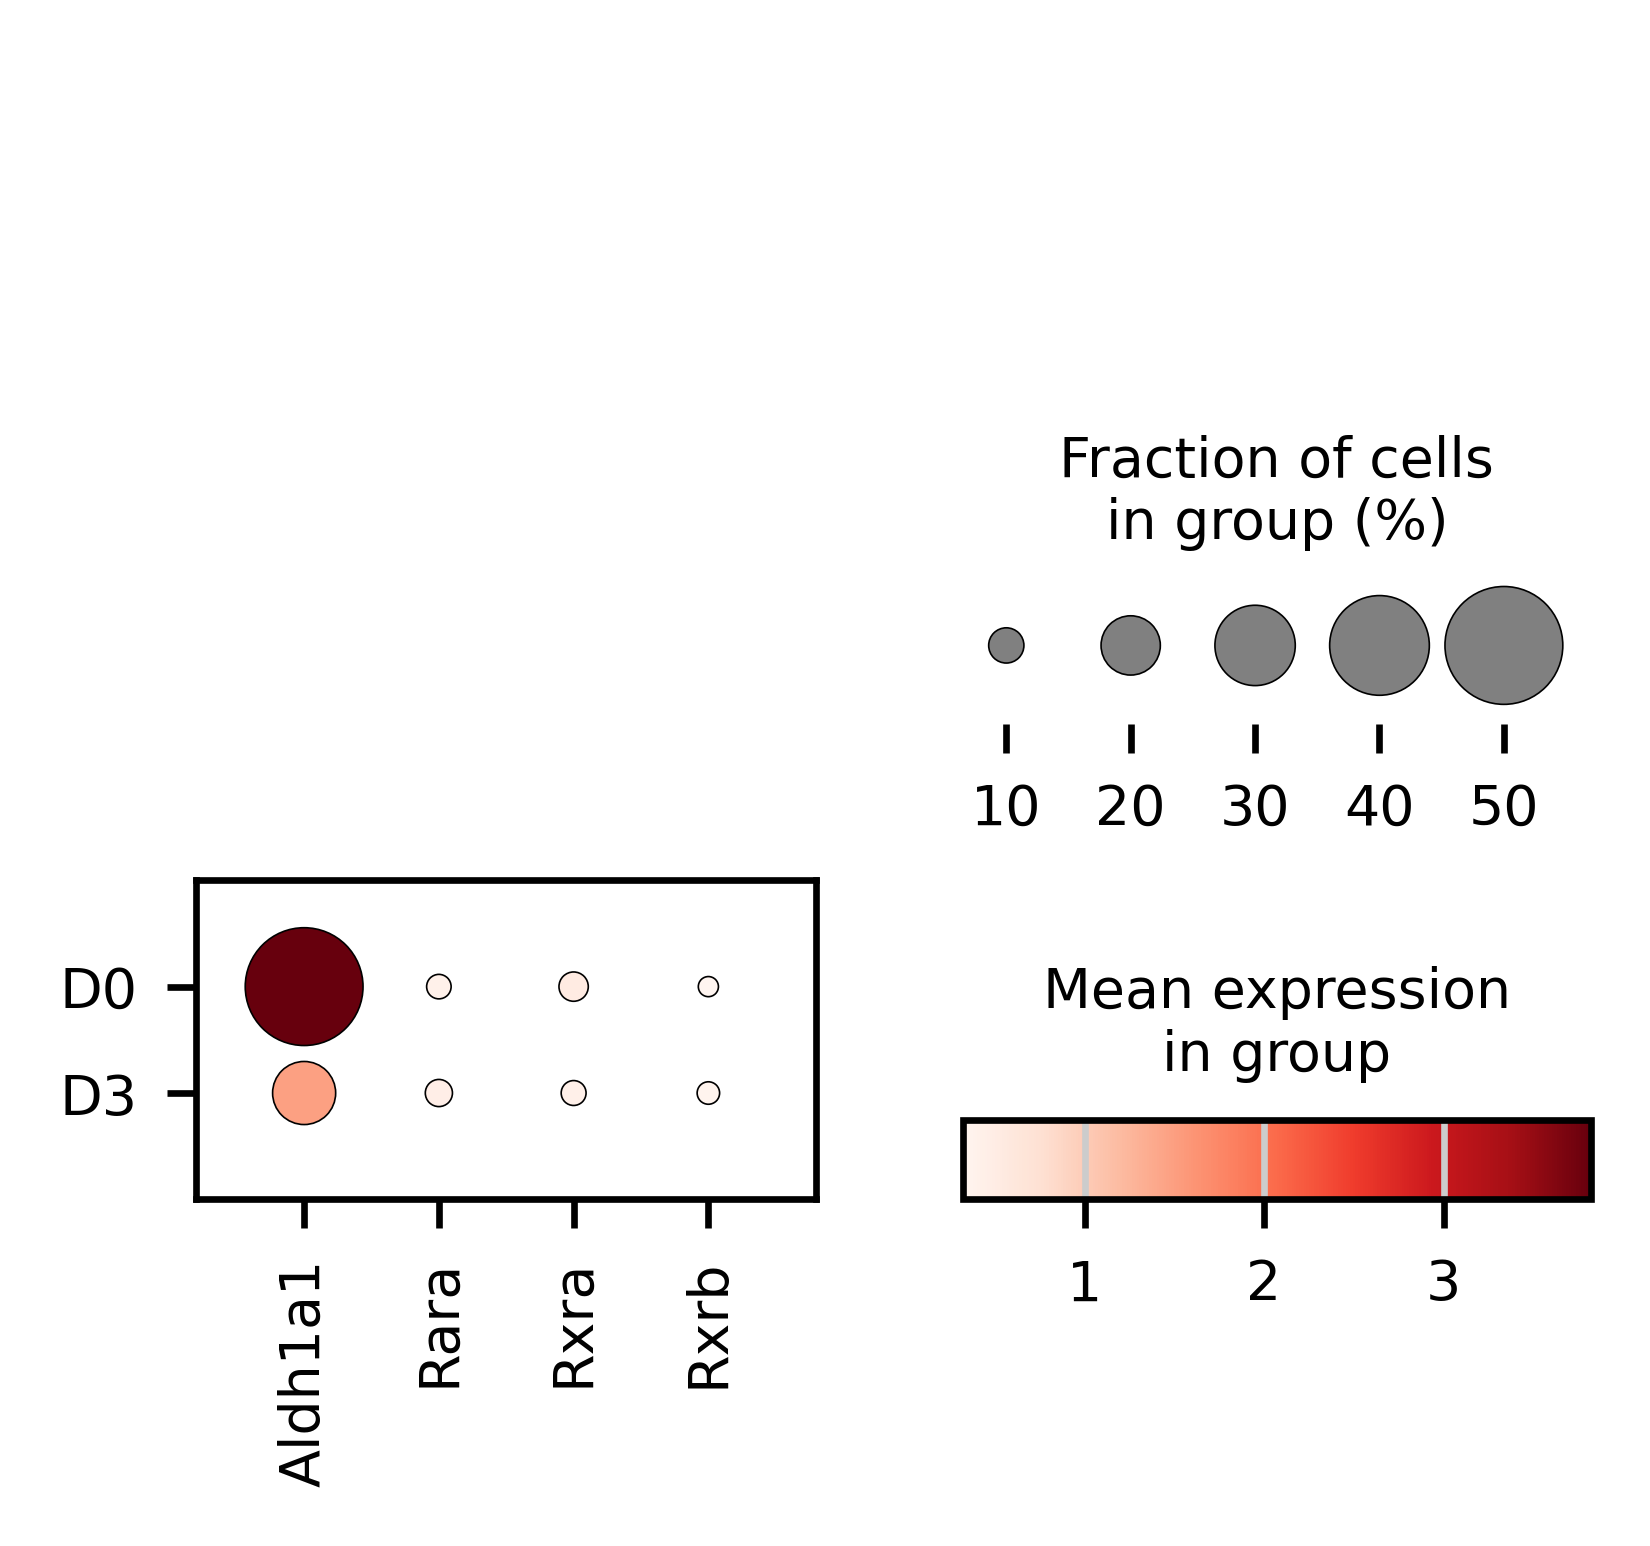

In [27]:
fts = ["Aldh1a1", "Aldh1a2", "Aldh1a3", "Rara", "Rxra", "Crabp2", "Rxrb", "Rarb", "Rarg", "Rorb"]
sc.pl.dotplot(adata_Verzi, fts, groupby = 'time')
fts = ['Aldh1a1', 'Rara', 'Rxra', 'Rxrb']
sc.pl.dotplot(adata_Verzi, fts, groupby = 'time')

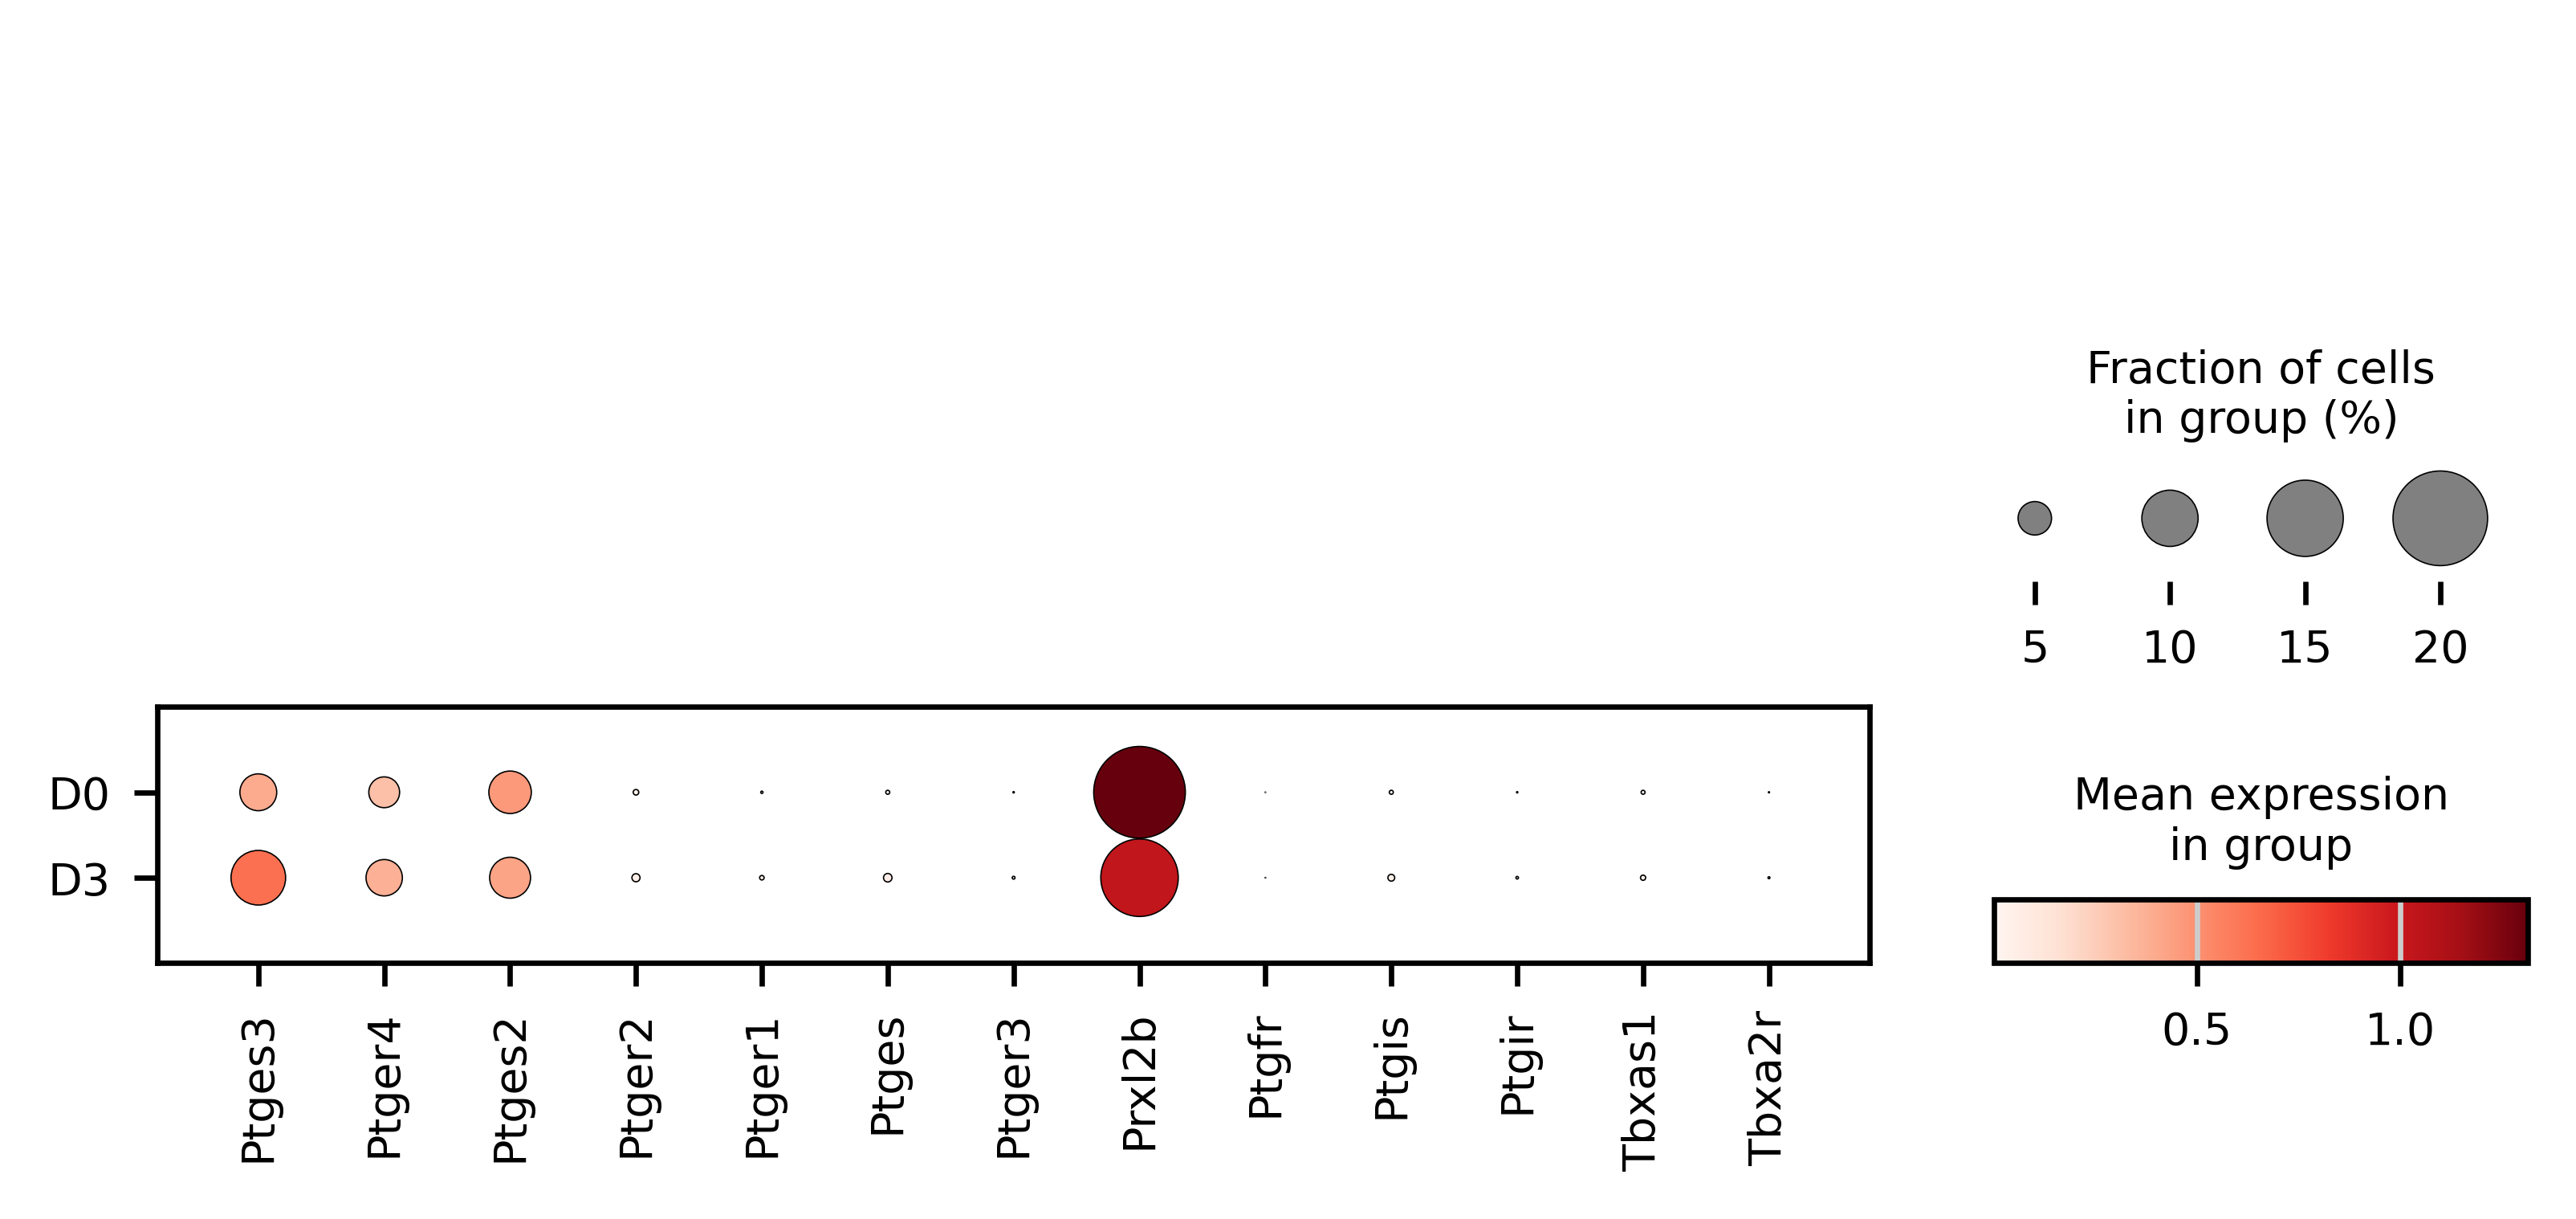

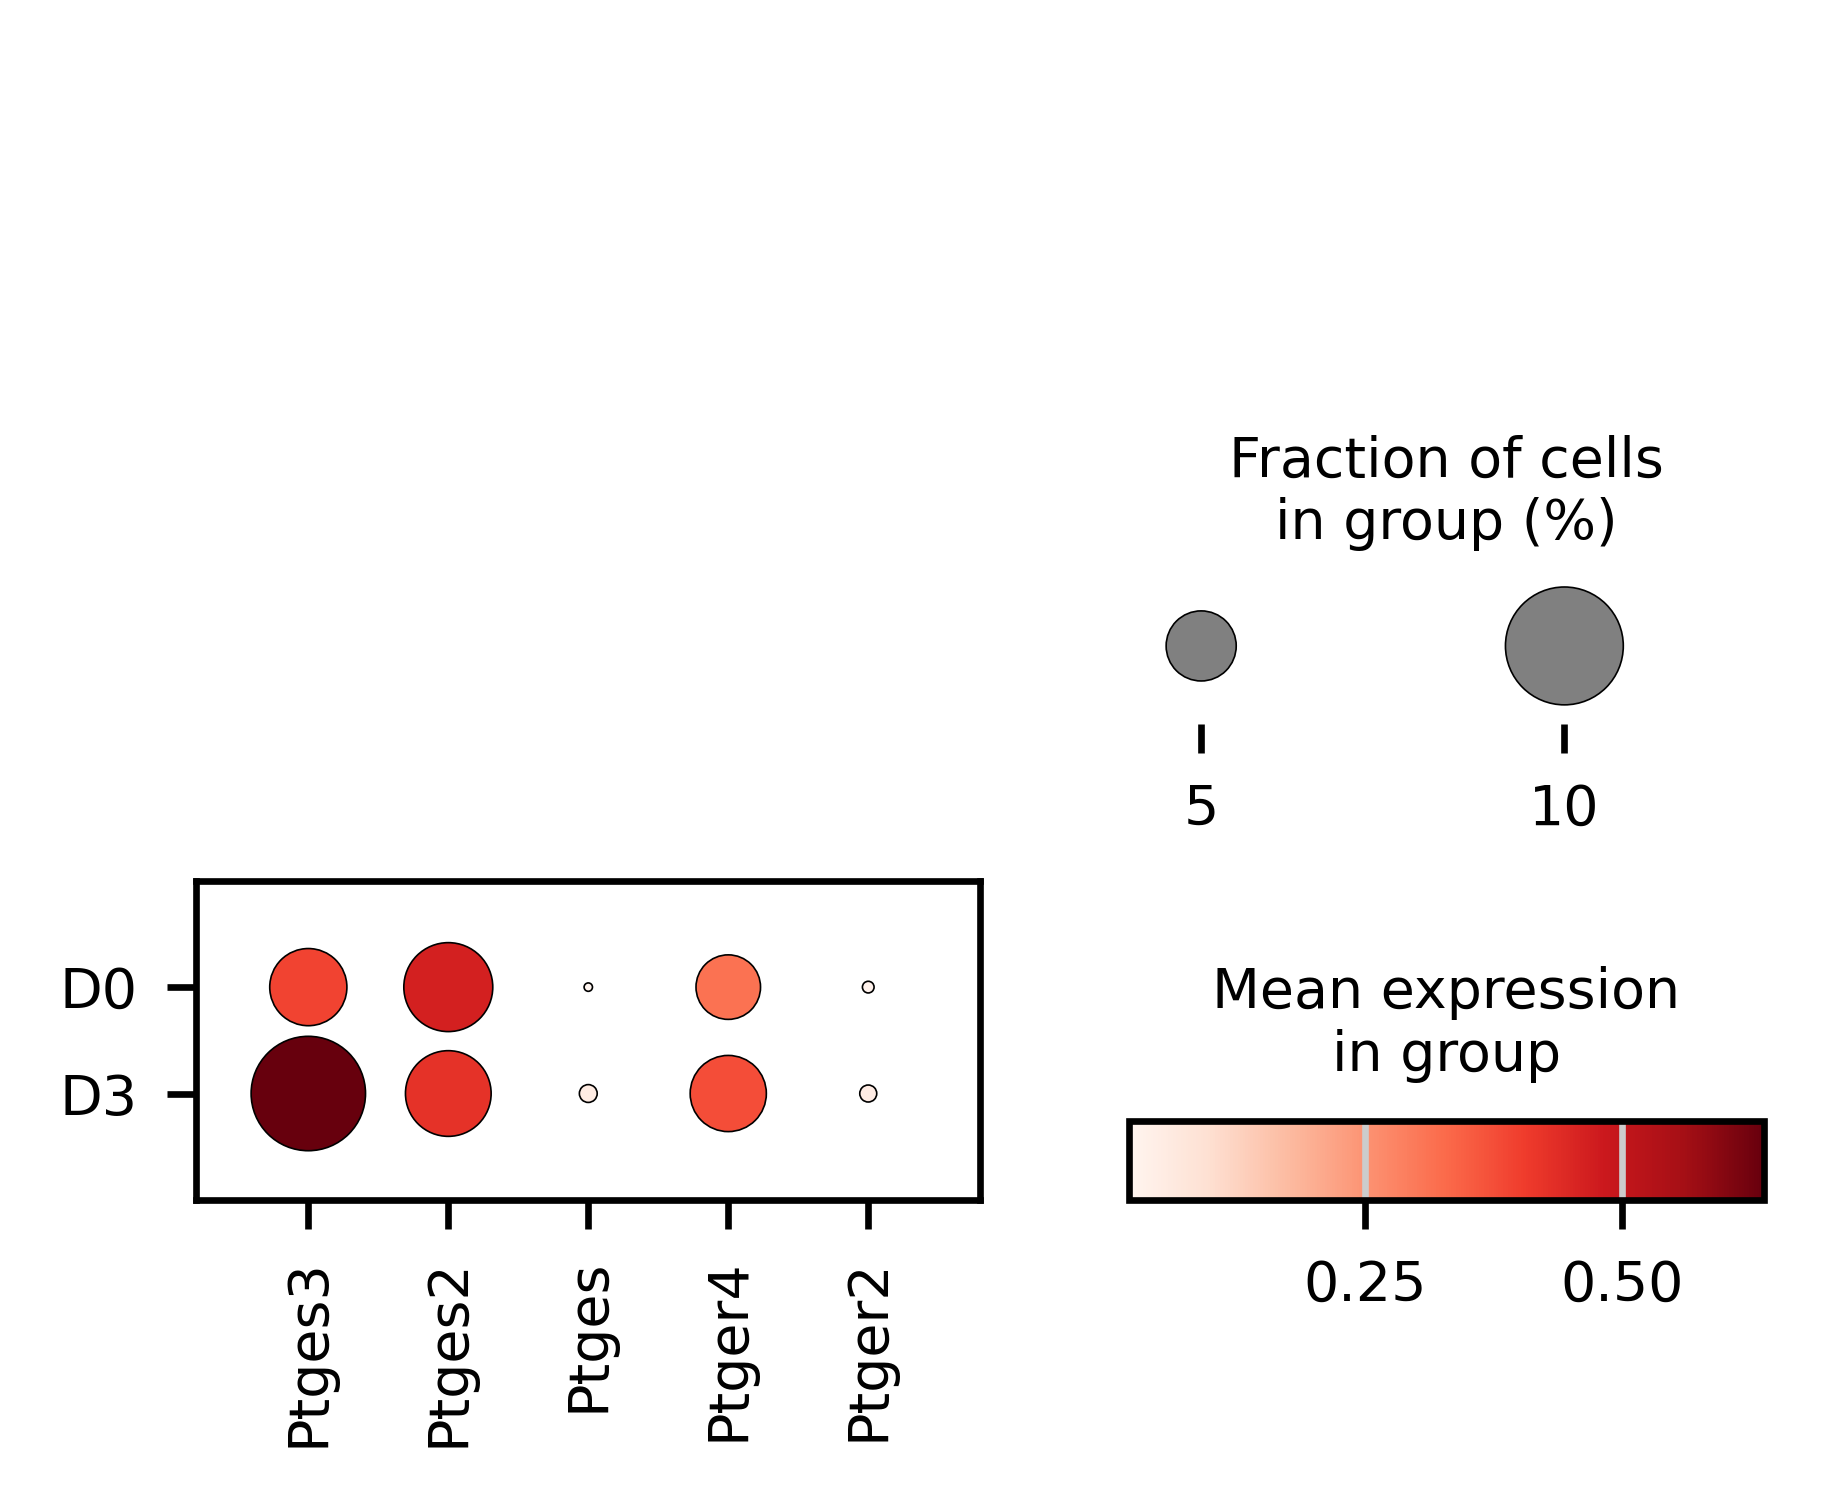

In [28]:
fts = ["Ptges3", "Ptger4", "Ptges2", "Ptger2", "Ptger1", "Ptges", "Ptger3", 
        "Prxl2b", "Ptgfr", "Ptgis", "Ptgir", "Tbxas1", "Tbxa2r"]
sc.pl.dotplot(adata_Verzi, fts, groupby = 'time')
fts = ['Ptges3', 'Ptges2', 'Ptges', 'Ptger4', 'Ptger2']
sc.pl.dotplot(adata_Verzi, fts, groupby = 'time')

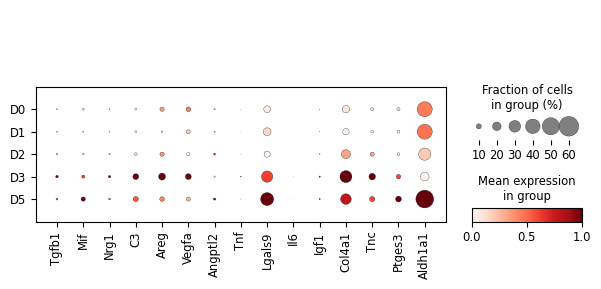

In [11]:

main = ['Tgfb1', 'Mif', 'Nrg1', 'C3', 'Areg', 'Vegfa', 'Angptl2', 'Tnf', 'Lgals9', 'Il6', 'Igf1', 'Col4a1', 'Tnc', 'Ptges3', 'Aldh1a1']
sc.pl.dotplot(adata_Verzi, main, groupby = 'time', standard_scale = 'var')

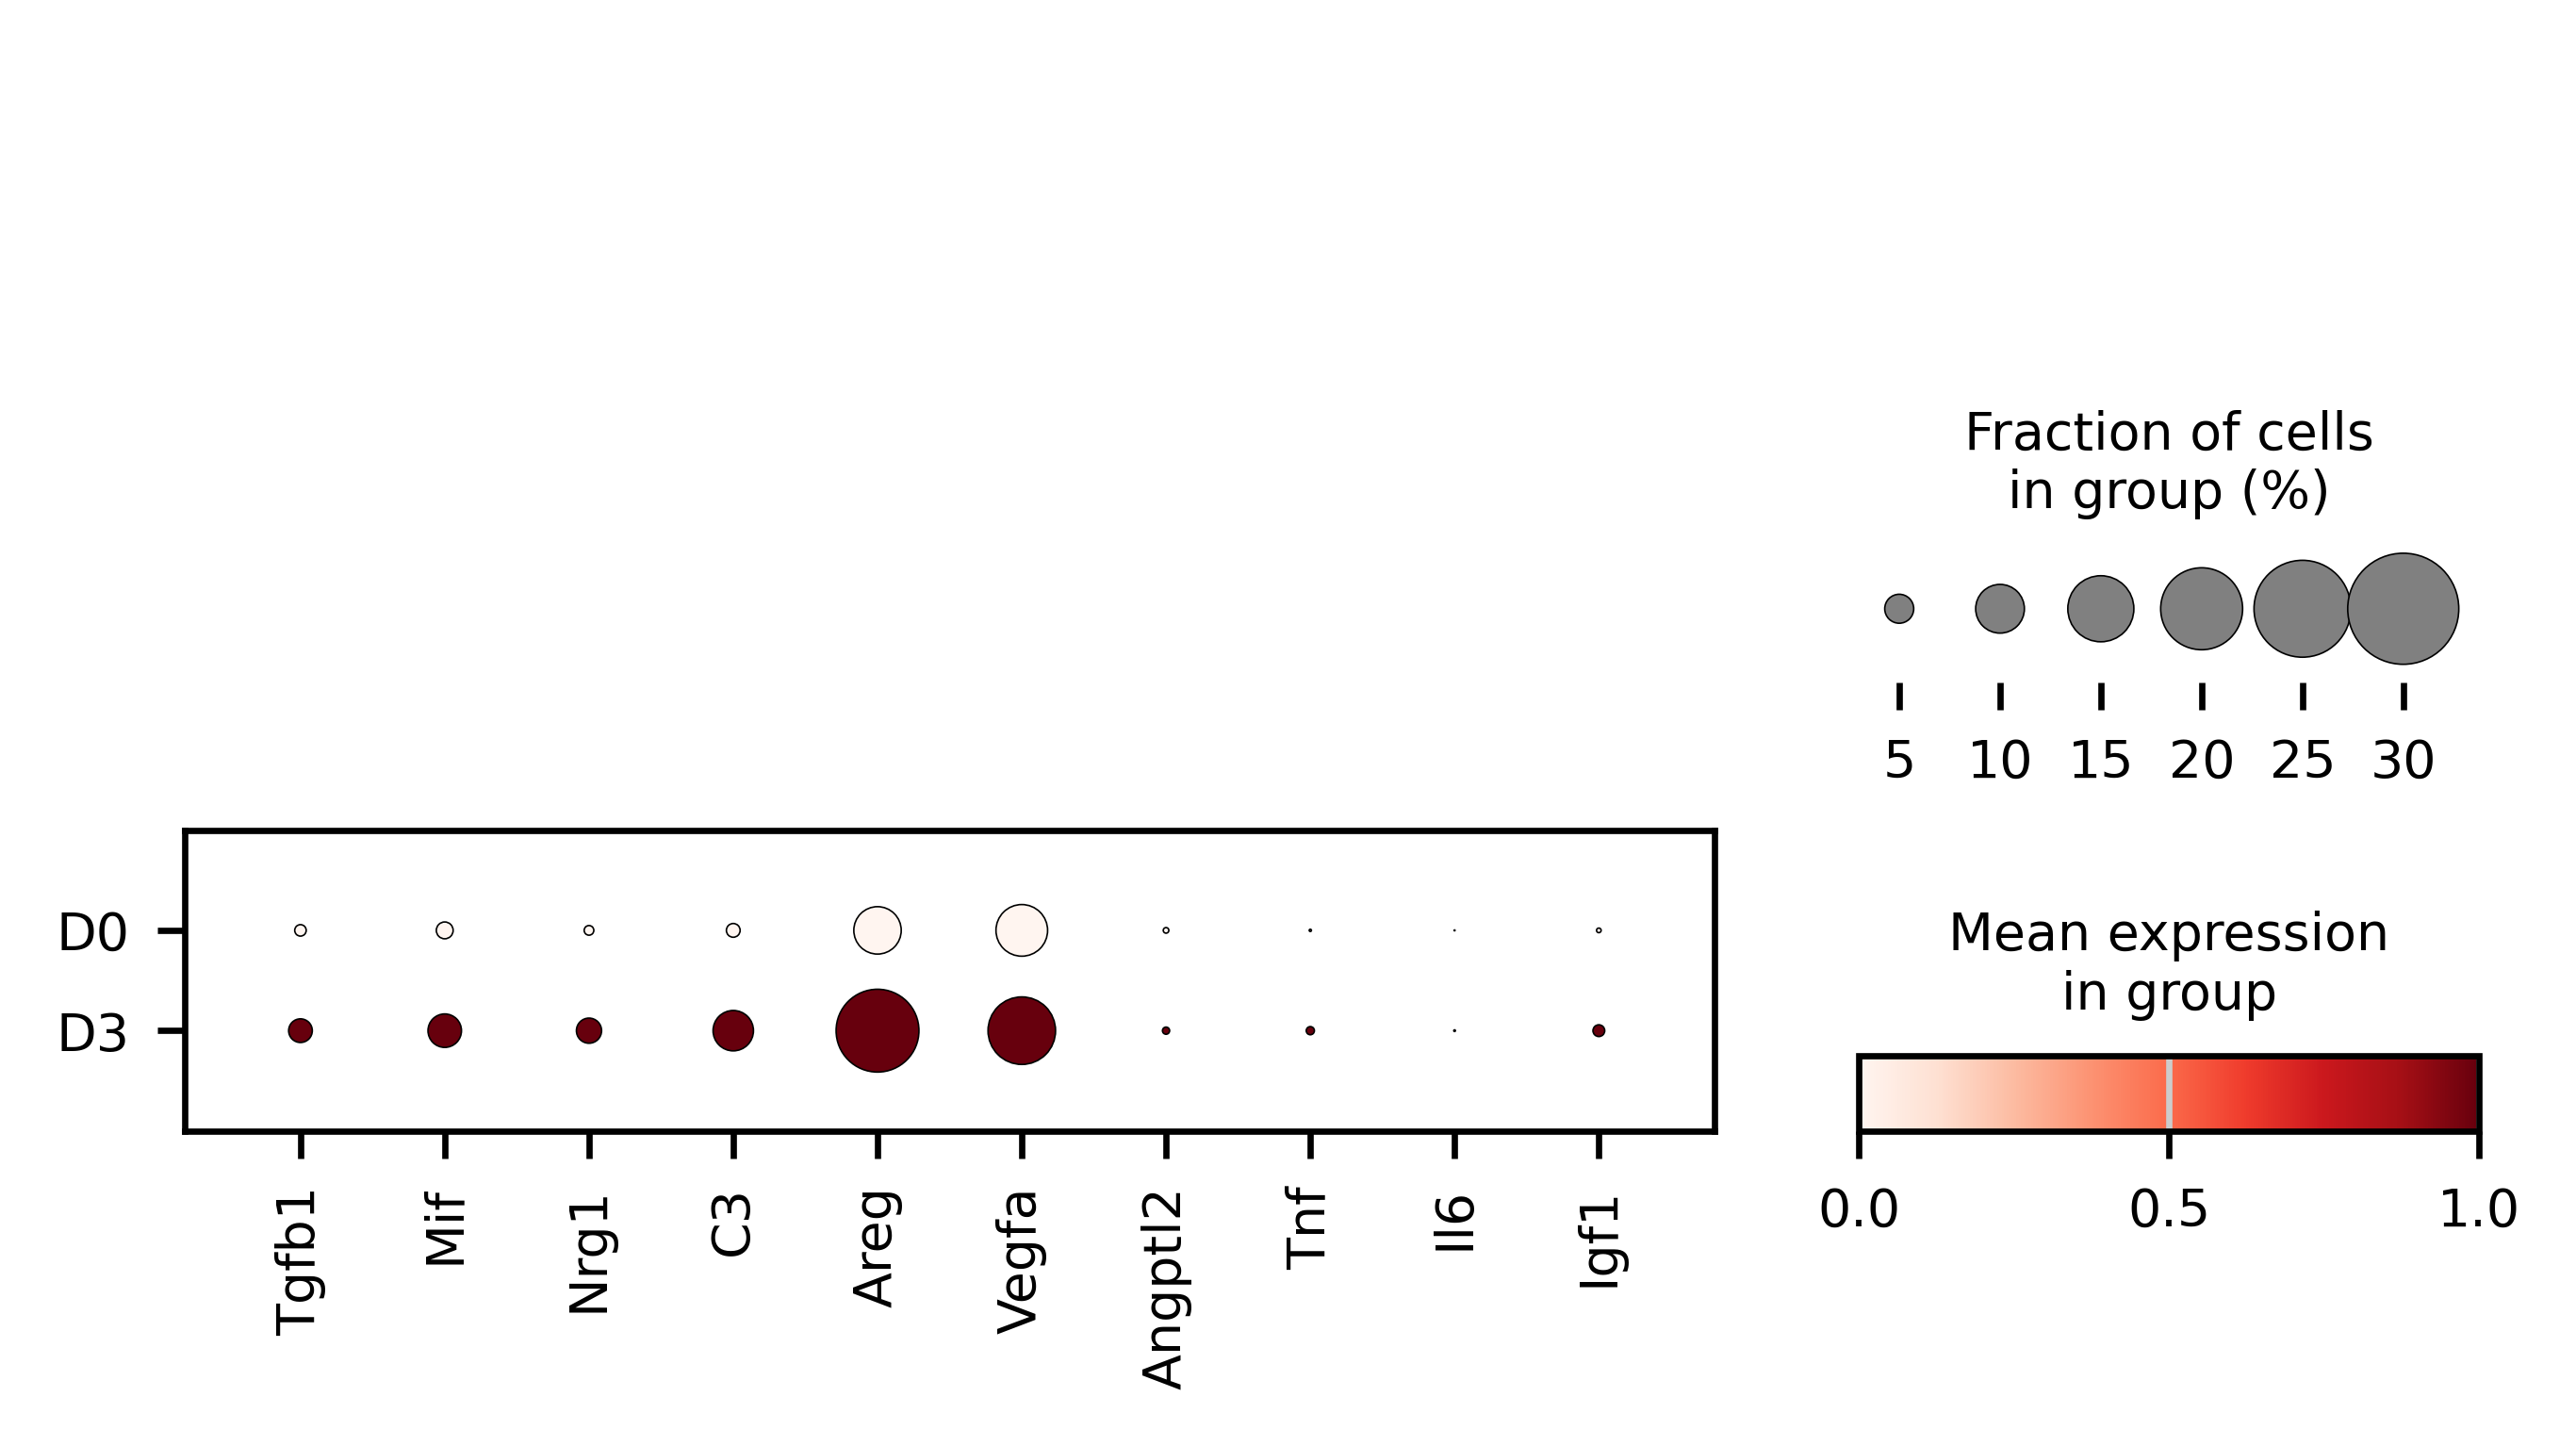

In [118]:
fts = ['Tgfb1', 'Mif', 'Nrg1', 'C3', 'Areg', 'Vegfa', 'Angptl2', 'Tnf', 'Lgals9', 'Il6', 'Igf1', 'Col4a1', 'Tnc']
sc.pl.dotplot(adata_Verzi, fts, groupby = 'time', standard_scale = 'var')

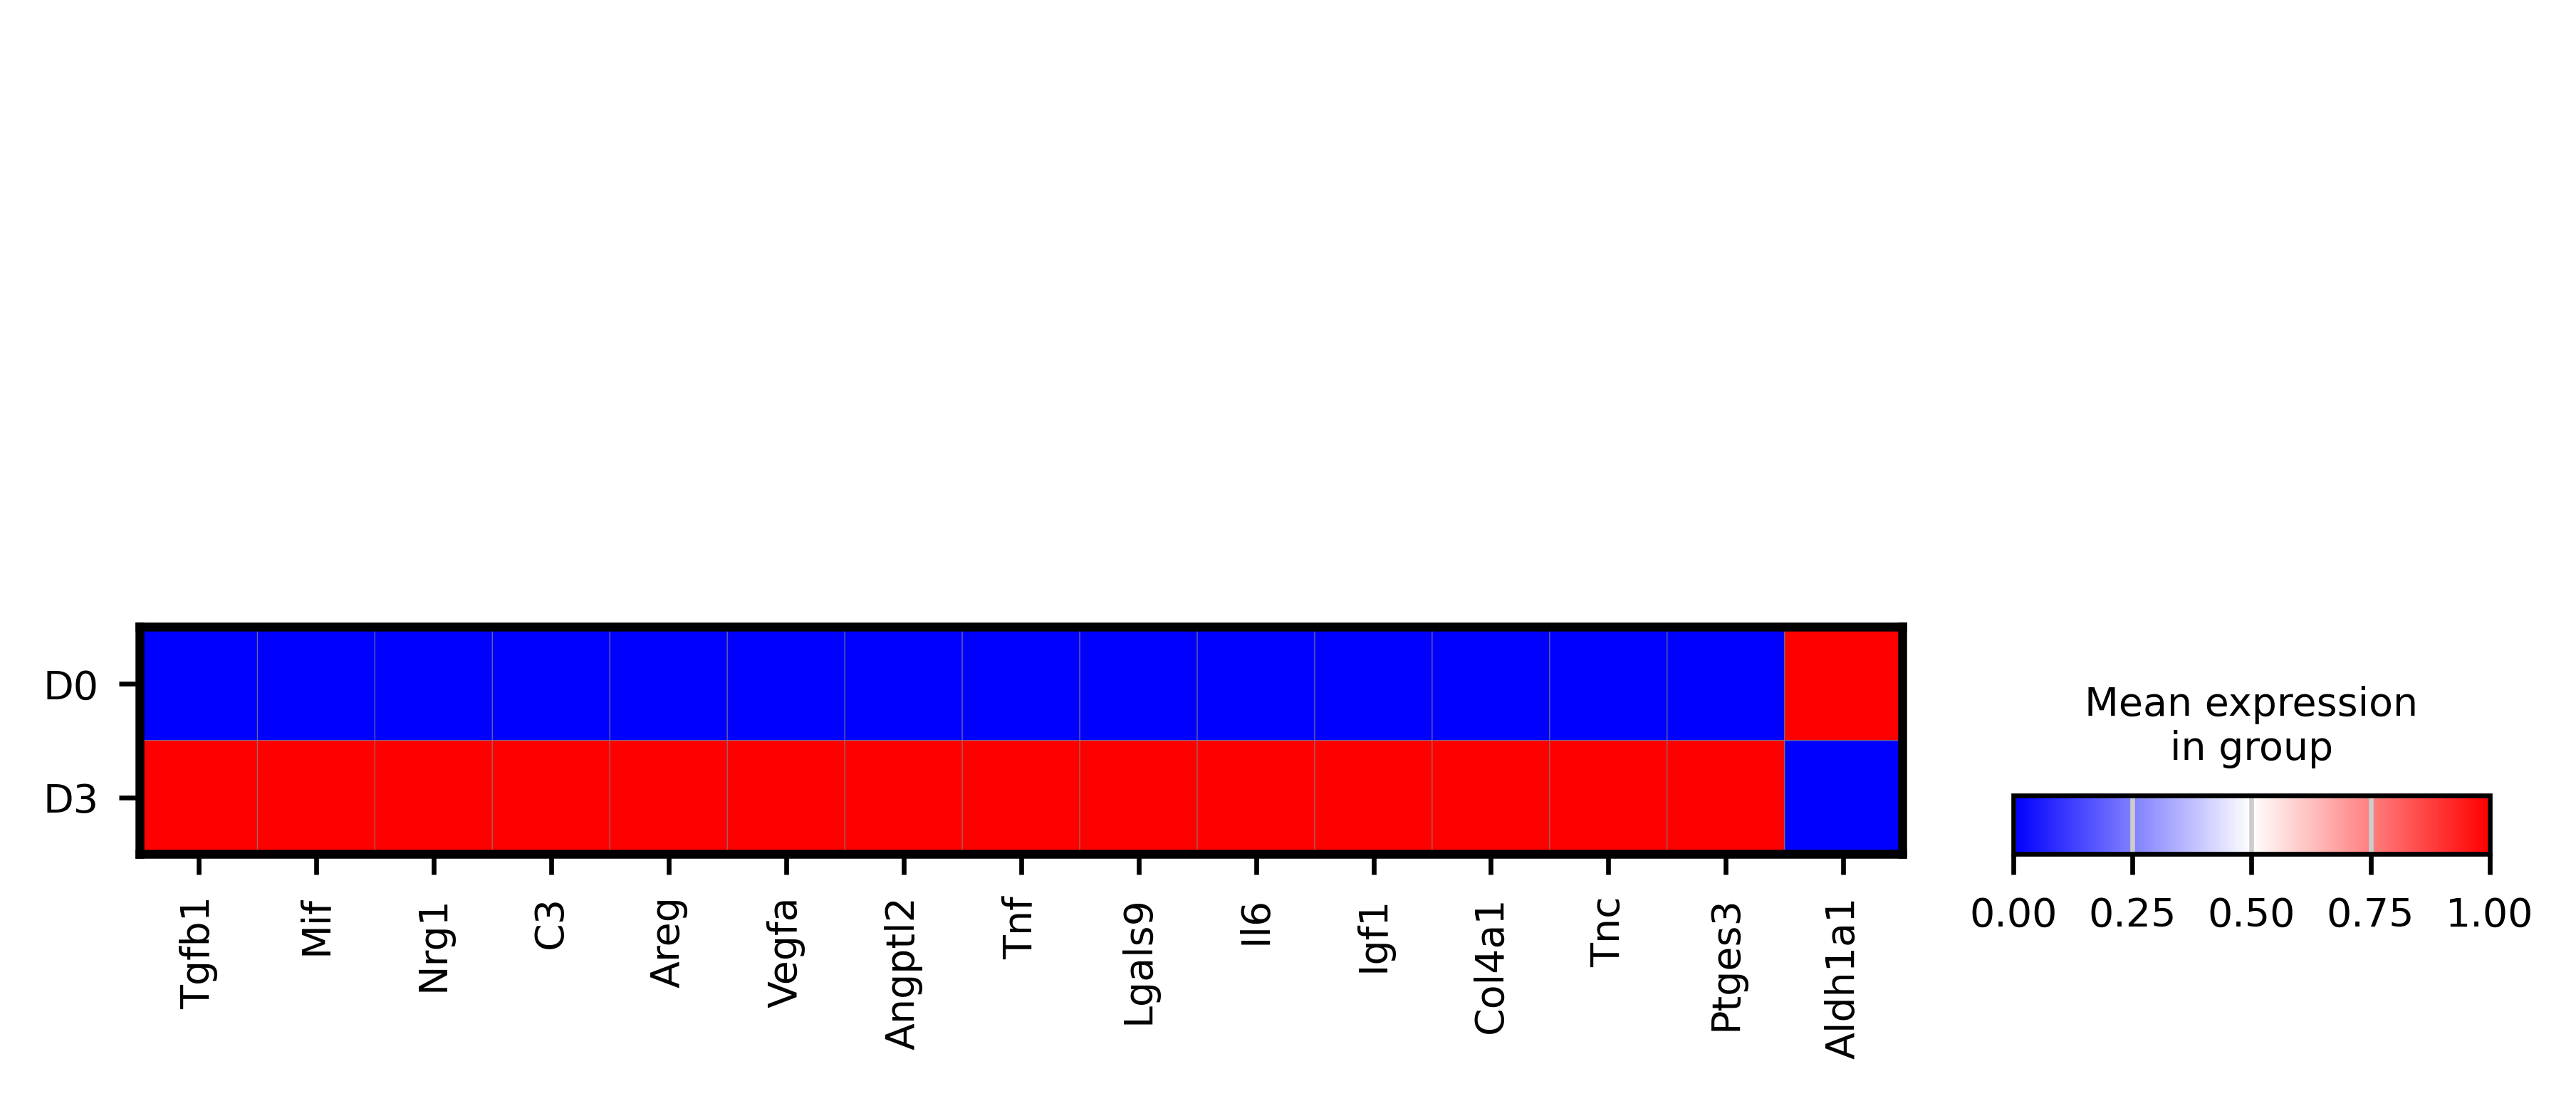

In [19]:
sc.pl.matrixplot(adata_Verzi, main, groupby = 'time', standard_scale = 'var', cmap = 'bwr')

#### part 2

In [25]:
adata_Verzi.obs['Epcam+'] = ['high_expression' if x >= 1 else 'low_expression' for x in adata_Verzi[:, 'Epcam'].X]
adata_Verzi.obs['Vil1+'] = ['high_expression' if x >= 1 else 'low_expression' for x in adata_Verzi[:, 'Vil1'].X]
adata_Verzi.obs['Mki67+'] = ['high_expression' if x >= 1 else 'low_expression' for x in adata_Verzi[:, 'Mki67'].X]

In [26]:
print(adata_Verzi.obs['Mki67+'].value_counts())

Mki67+
low_expression     324558
high_expression     22191
Name: count, dtype: int64


In [27]:

filtered_adata = adata_Verzi[
    (adata_Verzi.obs['Mki67+'] == 'high_expression') &
    ((adata_Verzi.obs['Epcam+'] == 'high_expression') | (adata_Verzi.obs['Vil1+'] == 'high_expression'))
].copy()

In [28]:
filtered_adata

AnnData object with n_obs × n_vars = 1173 × 19059
    obs: 'n_counts', 'time', 'stromalregions', 'Epcam+', 'Vil1+', 'Mki67+'
    var: 'gene_ids', 'feature_types', 'genome', 'mean', 'std'
    uns: 'log1p'

In [29]:
filtered_adata = filtered_adata[~filtered_adata.obs["time"].isna()]  # Remove NaNs


In [30]:
filtered_adata.obs['time'].value_counts()


time
D5    404
D1    268
D3    211
D0    192
D2     48
Name: count, dtype: int64

/home/tht38/anaconda3/envs/newenv/lib/python3.13/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/tht38/anaconda3/envs/newenv/lib/python3.13/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/tht38/anaconda3/envs/newenv/lib/python3.13/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


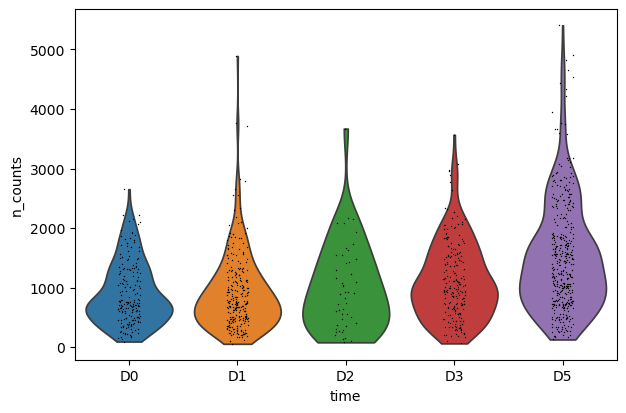

In [31]:
sc.pl.violin(filtered_adata, 'n_counts', groupby = 'time')

In [32]:
#print(filtered_adata.obs.groupby(['time'])[['n_counts','n_genes']].mean())


In [ ]:
gene_counts = pd.DataFrame(filtered_adata.X.toarray(), columns=filtered_adata.var.index)  # Convert sparse matrix to dense
gene_counts["time"] = filtered_adata.obs["time"].values

average_counts = (
    gene_counts.groupby("time")
    .mean()
    .transpose()  # Genes as rows, samples as columns
)

log_transformed_counts = np.log2(average_counts + 1)

log_transformed_counts["overall_mean"] = log_transformed_counts.mean(axis=1)
sorted_log_counts = log_transformed_counts.sort_values(by="overall_mean", ascending=False)

#x percent
top_10_percent = sorted_log_counts.iloc[: int(sorted_log_counts.shape[0] * 0.5)]

x = np.arange(top_10_percent.shape[0])
genes = top_10_percent.index

times = filtered_adata.obs["time"].unique()
custom_colors = {
    "D0": "#ff7f0e",
    "D1": "#0000ff",
    "D2": "#C589E2",
    "D3": "#00FFFF",
    'D5': '#FF0000'}
    

plt.figure(figsize=(14, 6))
for sampleIDs in filtered_adata.obs["time"].unique():
    y = top_10_percent[sampleIDs].values
    plt.scatter(x, y, label=sampleIDs, s= 5, alpha=0.4, color=custom_colors.get(sampleIDs), edgecolors='none',marker='o')

plt.xlabel("Top 50% of Genes (ordered by overall log-transformed average count)")
plt.ylabel("Log2(Counts + 1)")
plt.title("Log-Transformed Gene Expression (Top 50% of Genes) Across Samples")
plt.legend(title="Sample (sampleIDs)")
plt.ylim(0, 2)
#plt.xlim(0, 10000)
plt.xticks([], [])
plt.gca().invert_xaxis()
#plt.savefig('/home/tht38/spatial.python/rep2/rep2geneplot50.png', dpi = 600)
plt.tight_layout()



In [ ]:
gene_counts = pd.DataFrame(filtered_adata.X, columns=filtered_adata.var.index)  # Convert sparse matrix to dense
gene_counts["time"] = filtered_adata.obs["time"].values

average_counts = (
    gene_counts.groupby("time")
    .mean()
    .transpose()  # Genes as rows, samples as columns
)

log_transformed_counts = np.log2(average_counts + 1)

log_transformed_counts["overall_mean"] = log_transformed_counts.mean(axis=1)
sorted_log_counts = log_transformed_counts.sort_values(by="overall_mean", ascending=False)

#x percent
top_10_percent = sorted_log_counts.iloc[: int(sorted_log_counts.shape[0] * 0.5)]

x = np.arange(top_10_percent.shape[0])
genes = top_10_percent.index

times = filtered_adata.obs["time"].unique()
custom_colors = {
    "D0": "#ff7f0e",
    "D1": "#0000ff",
    "D2": "#C589E2",
    "D3": "#00FFFF",
    'D5': '#FF0000'}
    

plt.figure(figsize=(14, 6))
for sampleIDs in filtered_adata.obs["time"].unique():
    y = top_10_percent[sampleIDs].values
    plt.scatter(x, y, label=sampleIDs, s= 5, alpha=0.4, color=custom_colors.get(sampleIDs), edgecolors='none',marker='o')

plt.xlabel("Top 50% of Genes (ordered by overall log-transformed average count)")
plt.ylabel("Log2(Counts + 1)")
plt.title("Log-Transformed Gene Expression (Top 50% of Genes) Across Samples")
plt.legend(title="Sample (sampleIDs)")
#plt.ylim(0, 2)
#plt.xlim(0, 10000)
plt.xticks([], [])
plt.gca().invert_xaxis()
#plt.savefig('/home/tht38/spatial.python/rep2/rep2geneplot50.png', dpi = 600)
plt.tight_layout()



In [ ]:
filtered_adata.obs['sampleIDs'].unique()

['Control inner all', 'IR-D5 all', 'IR-D3 all', 'control all ', 'IR--D1 all']
Categories (5, object): ['Control inner all', 'IR--D1 all', 'IR-D3 all', 'IR-D5 all', 'control all ']

In [ ]:
# Step 1: Group cells by library_id and compute average counts for each gene
gene_counts = pd.DataFrame(filtered_adata.X.toarray(), columns=filtered_adata.var.index)  # Convert sparse matrix to dense
gene_counts["sampleIDs"] = filtered_adata.obs["sampleIDs"].values

# Calculate average counts for each gene per sample
average_counts = (
    gene_counts.groupby("sampleIDs")
    .mean()
    .transpose()  # Genes as rows, samples as columns
)

# Step 2: Check for genes where the sample of interest has the highest expression
is_highest = (average_counts['Control inner all'] >
              average_counts.drop(columns='Control inner all').max(axis=1))

# Step 3: Calculate the proportion
proportion_highest = is_highest.sum() / average_counts.shape[0]
print(f"Proportion of genes where {'Control inner all'} is higher than the others: {proportion_highest:.2%}")

# Step 2: Check for genes where the sample of interest has the highest expression
is_highest = (average_counts['control all '] >
              average_counts.drop(columns='control all ').max(axis=1))

# Step 3: Calculate the proportion
proportion_highest = is_highest.sum() / average_counts.shape[0]
print(f"{'control all '} is higher than the others: {proportion_highest:.2%}")

# Step 2: Check for genes where the sample of interest has the highest expression
is_highest = (average_counts['IR--D1 all'] >
              average_counts.drop(columns='IR--D1 all').max(axis=1))

# Step 3: Calculate the proportion
proportion_highest = is_highest.sum() / average_counts.shape[0]
print(f"{'IR--D1 all'} is higher than the others: {proportion_highest:.2%}")

# Step 2: Check for genes where the sample of interest has the highest expression
is_highest = (average_counts['IR-D3 all'] >
              average_counts.drop(columns='IR-D3 all').max(axis=1))

# Step 3: Calculate the proportion
proportion_highest = is_highest.sum() / average_counts.shape[0]
print(f"{'IR-D3 all'} is higher than the others: {proportion_highest:.2%}")
# Step 2: Check for genes where the sample of interest has the highest expression
is_highest = (average_counts['IR-D5 all'] >
              average_counts.drop(columns='IR-D5 all').max(axis=1))

# Step 3: Calculate the proportion
proportion_highest = is_highest.sum() / average_counts.shape[0]
print(f"{'IR-D5 all'} is higher than the others: {proportion_highest:.2%}")


In [ ]:
# Step 1: Group cells by library_id and compute average counts for each gene
gene_counts = pd.DataFrame(filtered_adata.X.toarray(), columns=filtered_adata.var.index)  # Convert sparse matrix to dense
gene_counts["sampleIDs"] = filtered_adata.obs["sampleIDs"].values

# Calculate average counts for each gene per sample
average_counts = (
    gene_counts.groupby("sampleIDs")
    .mean()
    .transpose()  # Genes as rows, samples as columns
)


is_lowest = (average_counts["Control inner all"] <
             average_counts.drop(columns="Control inner all").min(axis=1))

# Step 2: Calculate the proportion of genes where "Day 0 irradiation" has the lowest expression
proportion_lowest = is_lowest.sum() / average_counts.shape[0]

# Step 3: Print the result
print(f"Proportion of genes where Control inner all has the lowest average expression: {proportion_lowest:.2%}")


is_lowest = (average_counts["control all "] <
             average_counts.drop(columns="control all ").min(axis=1))

# Step 2: Calculate the proportion of genes where "Day 0 irradiation" has the lowest expression
proportion_lowest = is_lowest.sum() / average_counts.shape[0]

# Step 3: Print the result
print(f"control all  has the lowest average expression: {proportion_lowest:.2%}")

is_lowest = (average_counts["IR--D1 all"] <
             average_counts.drop(columns="IR--D1 all").min(axis=1))

# Step 2: Calculate the proportion of genes where "Day 0 irradiation" has the lowest expression
proportion_lowest = is_lowest.sum() / average_counts.shape[0]

# Step 3: Print the result
print(f"IR--D1 all has the lowest average expression: {proportion_lowest:.2%}")

is_lowest = (average_counts["IR-D3 all"] <
             average_counts.drop(columns="IR-D3 all").min(axis=1))

# Step 2: Calculate the proportion of genes where "Day 0 irradiation" has the lowest expression
proportion_lowest = is_lowest.sum() / average_counts.shape[0]

# Step 3: Print the result
print(f"IR-D3 all has the lowest average expression: {proportion_lowest:.2%}")

is_lowest = (average_counts["IR-D5 all"] <
             average_counts.drop(columns="IR-D5 all").min(axis=1))

# Step 2: Calculate the proportion of genes where "Day 0 irradiation" has the lowest expression
proportion_lowest = is_lowest.sum() / average_counts.shape[0]

# Step 3: Print the result
print(f"IR-D5 all has the lowest average expression: {proportion_lowest:.2%}")

Proportion of genes where Control inner all has the lowest average expression: 3.78%
control all  has the lowest average expression: 17.34%
IR--D1 all has the lowest average expression: 31.54%
IR-D3 all has the lowest average expression: 15.43%
IR-D5 all has the lowest average expression: 2.26%
